# Network Creation and analysis

The following Notebook contains the code used for the creation of the lexical dynamic network and its subsequent analyses. The **iGraph** library is requested.

In [1]:
import pandas as pd
import pyphen
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from collections import Counter, defaultdict
import igraph as ig
from tqdm import tqdm  # Per la barra di avanzamento
import math
import numpy as np

## 1. Dynamic graph creation

The subsequent code creates a weighted (by similarity) graph for each snapshot using **ipgraph** library. Each node is labelled with:

- Its corresponding *token*;
- The *frequency* of the corresponding token;


In [ ]:
edges_dir = Path("../edges_analysis/edges")
vec_dir = Path("../embedding/word_embeddings_all")
freq_dir = Path("../embedding/frequencies_all")

output_dir = Path("networks")
output_dir.mkdir(exist_ok=True)

percentile = 99

print("[START] Costruzione grafi igraph con freq nodo")

for snap in range(1, 11):
    t0 = time.time()

    edges_tsv = edges_dir / f"edges_snap{snap}_p{percentile}.tsv"
    vec_file = vec_dir / f"fasttext_snap{snap}_filt.vec"
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"
    out_graph = output_dir / f"graph_snap{snap}_p{percentile}.igp"

    print(f"\n[SNAPSHOT {snap}]")

    # archi
    df_edges = pd.read_csv(edges_tsv, sep="\t")

    src = df_edges.iloc[:, 0].astype(int).to_numpy()
    dst = df_edges.iloc[:, 1].astype(int).to_numpy()

    has_weight = df_edges.shape[1] > 2
    if has_weight:
        weights = df_edges.iloc[:, 2].astype(float).to_numpy()

    #token
    tokens = []
    with open(vec_file, encoding="utf-8") as f:
        next(f)
        for line in f:
            tokens.append(line.split()[0])

    n_nodes = len(tokens)

    # freq
    freq_map = {}
    read_csv = pd.read_csv(freq_file)
    for _, row in read_csv.iterrows():
        freq_map[row["lemma"]] = row["frequency"]
        
    # allineamento token → freq (0 se assente)
    freqs = [freq_map.get(tok, 0) for tok in tokens]

    # grafo
    g = ig.Graph(n=n_nodes, directed=False)

    g.vs["token"] = tokens
    g.vs["freq"] = freqs

    g.add_edges(zip(src, dst))

    if has_weight:
        g.es["weight"] = weights

    # salvo
    g.write_pickle(out_graph)

    print(
        f"[DONE] nodi={n_nodes}, archi={g.ecount()}, "
        f"freq=yes, peso={'sì' if has_weight else 'no'} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i grafi salvati")

In [ ]:
# per importare:

g = ig.Graph.Read_Pickle("networks/graph_snap3_p99.igp")

print(g.vs[0]["token"], g.vs[0]["freq"])
print(g.vs[100]["token"], g.vs[100]["freq"])

print(g.es[0]["weight"])


# 2. Node Labelling
For the Complexity labelling, 3 metrics are merged:

1. **Morphological Complexity**: By the Zipf Law (or law of least effort) complex words are inveresely proportional to their length in terms of characters and syllables.
2. **De Mauro's list of common words**: common words can be Fundamentals (high frequency words, 90% coverage of texts), High Usage (6-8% coverage of texts) and High Availability (common but rarely used words). A complex word doesn't belong to any of these sets. 
3. **Inverse Document Frequency**: A generic/less complex word tends to appear more frequently than a complex/high informative word.

In [ ]:
# --- 1. SETUP INIZIALE ---
dic = pyphen.Pyphen(lang='it_IT')

# Carica De Mauro (NVdB)
# Assicurati che 'lemma' sia la colonna giusta e non ci siano duplicati
try:
    nvdb = pd.read_csv('nvdb.csv').set_index('lemma')['categoria'].to_dict()
except Exception as e:
    print(f"Attenzione: Errore caricamento NVdB ({e}). I nodi avranno valore default.")
    nvdb = {}

# Mapping punteggi De Mauro
demauro_scores = {'FO': 0, 'AU': 1, 'AD': 2, 'Altro': 3} # più basso è il punteggio, più facile (meno complessa) è la parola

# --- 2. PRE-CALCOLO DOCUMENT FREQUENCY ---
freq_doc_path = Path("../embedding/frequencies_all")
doc_freq_counter = Counter()
total_docs = 0

print("Pre-calcolo delle frequenze documentali (DF)...")
files_list = list(freq_doc_path.glob("*.csv"))
total_docs = len(files_list)

# Leggiamo ogni CSV una volta sola e aggiorniamo il contatore globale
for file_path in tqdm(files_list):
    try:
        df = pd.read_csv(file_path)
        # Prendiamo i lemmi unici in questo documento
        unique_lemmas = set(df['lemma'].dropna().unique()) # Evita NaN e duplicati
        doc_freq_counter.update(unique_lemmas) # Aggiorna il contatore globale
    except Exception as e:
        print(f"Errore lettura {file_path}: {e}")

print(f"DF calcolata su {total_docs} documenti.")

# --- 3. FUNZIONE COMPLESSITÀ VETTORIZZATA ---
def compute_metrics(lemma):
    """Calcola le metriche per un singolo lemma usando i dati pre-caricati"""
    if not isinstance(lemma, str): 
        return 0, 0, 3, 0.0 # Valori default per nodi sporchi
    
    # A. Lunghezza
    char_len = len(lemma)
    syll_len = len(dic.inserted(lemma).split('-'))
    
    # B. De Mauro
    cat = nvdb.get(lemma, 'Altro')
    dm_score = demauro_scores.get(cat, 3)
    
    # C. IDF
    # Recupera il conteggio dal dizionario pre-calcolato
    df_val = doc_freq_counter.get(lemma, 0)
    # Formula IDF standard con smoothing
    idf = math.log(total_docs / (1 + df_val)) if total_docs > 0 else 0 # una parola complessa ha IDF alto (perché il denominatore è basso)
    
    return char_len, syll_len, dm_score, idf

# --- 4. ETICHETTATURA DEI GRAFI (IGRAPH) ---
output_dir = Path("networks")
processed_dir = Path("networks_annotated") # Salvataggio in cartella nuova
processed_dir.mkdir(exist_ok=True)

graph_files = list(output_dir.glob("graph_snap*_p99.igp"))

for graph_path in tqdm(graph_files, desc="Annotazione Grafi"):
    
    # Carica Grafo
    try:
        G = ig.Graph.Read_Pickle(str(graph_path))
    except:
        print(f"Errore apertura {graph_path}")
        continue

    # In igraph, gli attributi dei nodi si leggono/scrivono meglio in batch (liste)
    # Assumiamo che l'attributo che contiene la parola si chiami 'name' o 'token'
    # Igraph usa 'name' come ID di default nei GraphML/Pickle solitamente.
    node_attr_name = 'name' if 'name' in G.vs.attributes() else 'token'
    
    lemmas = G.vs[node_attr_name] # Ottieni lista di tutte le parole
    
    # Liste per i nuovi attributi
    list_char = []
    list_syll = []
    list_dm = []
    list_idf = []
    
    # Calcola metriche per ogni nodo
    for lemma in lemmas:
        c, s, d, i = compute_metrics(lemma)
        list_char.append(c)
        list_syll.append(s)
        list_dm.append(d)
        list_idf.append(i)
    
    # Assegnazione in blocco (Molto più veloce di .update() nodo per nodo)
    G.vs["char_len"] = list_char
    G.vs["syll_len"] = list_syll
    G.vs["demauro_level"] = list_dm
    G.vs["idf"] = list_idf
    
    # Salva il nuovo grafo annotato
    out_path = processed_dir / graph_path.name
    G.write_pickle(str(out_path))

print("Finito! Grafi annotati salvati in networks_annotated/")


Pre-calcolo delle frequenze documentali (DF)...


100%|██████████| 10/10 [00:01<00:00,  9.86it/s]


DF calcolata su 10 documenti.


Annotazione Grafi: 100%|██████████| 10/10 [19:03<00:00, 114.36s/it]

Finito! Grafi annotati salvati in networks_annotated/


## 3. Network analyses

### 3.1) Simple networks statistics

In [ ]:
import gc # Garbage Collector per liberare RAM

input_dir = "./networks"
rows = []

# Imposta su False se vuoi un risultato immediato per testare
CALCOLA_CLUSTERING = True 

print(f"Inizio analisi su {input_dir}...")

for file in sorted(os.listdir(input_dir)):
    if not "snap" in file: continue # sicurezza
    
    # Estrazione tempo
    try:
        t = int(file.split("_")[1].replace("snap", ""))
    except:
        continue

    print(f"Analisi {t}...", end="")

    try:
        # Caricamento
        path = os.path.join(input_dir, file)
        
        Gt = ig.Graph.Read_Pickle(path) 

        num_nodes = Gt.vcount()
        num_edges = Gt.ecount()

        # 1. Density (Calcolo aritmetico istantaneo)
        possible_edges = (num_nodes * (num_nodes - 1) / 2)
        density = num_edges / possible_edges if num_nodes > 1 else 0

        # 2. Avg Degree (Veloce)
        # mean() nativo di python è leggermente meglio del calcolo manuale su liste enormi
        degrees = Gt.degree()
        avg_degree = sum(degrees) / num_nodes if num_nodes > 0 else 0

        # 3. Componenti Connesse (OTTIMIZZATO)
        # Chiamiamo l'algoritmo UNA volta sola
        if num_nodes > 0:
            clusters = Gt.connected_components(mode="weak")
            num_components = len(clusters)
            # .sizes() restituisce una lista di interi direttamente dal C -> Velocissimo
            sizes = clusters.sizes()
            largest_cc = max(sizes) if sizes else 0
        else:
            num_components = 0
            largest_cc = 0

        # 4. Clustering Coefficient (IL PUNTO CRITICO)
        if CALCOLA_CLUSTERING and num_edges > 0:
            # Usa transitivity_undirected() (Globale) invece di avglocal.
            # È drasticamente più veloce su grafi densi.
            clustering_coefficient = Gt.transitivity_undirected()
        else:
            clustering_coefficient = 0

        rows.append({
            "time": t,
            "nodes": num_nodes,
            "edges": num_edges,
            "density": density,
            "avg_degree": avg_degree,
            "components": num_components,
            "largest_cc": largest_cc,
            "clustering": clustering_coefficient
        })

        print(f" Fatto. (N={num_nodes}, E={num_edges})")

        # Pulizia memoria esplicita
        del Gt
        del clusters
        del degrees
        gc.collect()

    except Exception as e:
        print(f" Errore su {file}: {e}")

# Output
pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.width', 1000)
df = pd.DataFrame(rows).sort_values("time")

print("\nRisultati Finali:")
print(df)

Inizio analisi su ./networks...
Analisi 10... Fatto. (N=49340, E=11964184)
Analisi 1... Fatto. (N=50128, E=12169053)
Analisi 2... Fatto. (N=47828, E=11035778)
Analisi 3... Fatto. (N=64670, E=20314009)
Analisi 4... Fatto. (N=65248, E=21038711)
Analisi 5... Fatto. (N=76600, E=28498747)
Analisi 6... Fatto. (N=84416, E=34398376)
Analisi 7... Fatto. (N=65212, E=20804061)
Analisi 8... Fatto. (N=59269, E=17188815)
Analisi 9... Fatto. (N=53359, E=14015080)

Risultati Finali:
   time  nodes     edges  density  avg_degree  components  largest_cc  clustering
1     1  50128  12169053 0.009686  485.519191         669       49460    0.257543
2     2  47828  11035778 0.009649  461.477712         640       47189    0.256557
3     3  64670  20314009 0.009715  628.235936         484       64187    0.267371
4     4  65248  21038711 0.009884  644.884472         618       64631    0.266243
5     5  76600  28498747 0.009714  744.092611        1114       75486    0.252832
6     6  84416  34398376 0.009654  8

### 3.2) Node persistence analysis

Which are the persistent and volatile words?

In [ ]:
input_dir = Path("networks")
files = sorted([f for f in os.listdir(input_dir) if "snap" in f])

# Dizionario: chiave = parola, valore = set di anni in cui appare
word_presence = defaultdict(set)
all_years = []

print("Estrazione vocabolario temporale...")

for file in files:
    # Estrai anno dal nome file (es. graph_snap1960_p99.igp -> 1960)
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except:
        continue
        
    all_years.append(year)
    
    # Carica grafo
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    # Ottieni lista nodi 
    node_names = G.vs['token'] 
    
    for word in node_names:
        word_presence[word].add(year)

print(f"Analizzati {len(all_years)} snapshot.")

# --- CREAZIONE DATAFRAME DI ANALISI ---
rows = []
total_snapshots = len(all_years)

for word, years in word_presence.items():
    rows.append({
        "lemma": word,
        "count": len(years),                   # In quanti snap c'è
        "persistence_score": len(years) / total_snapshots, # % presenza (0-1)
        "first_seen": min(years),              # Anno nascita
        "last_seen": max(years),               # Anno morte (o ultimo rilevamento)
        "is_always_present": len(years) == total_snapshots
    })

df_persistence = pd.DataFrame(rows).sort_values("count", ascending=False)

# --- STATISTICHE ---
avg_appearance = df_persistence['count'].mean()
median_appearance = df_persistence['count'].median()

print(f"\n--- RISULTATI PERSISTENZA ---")
print(f"Parole totali uniche nel corpus: {len(df_persistence)}")
print(f"Media snapshot per parola: {avg_appearance:.2f} su {total_snapshots}")
print(f"Mediana snapshot per parola: {median_appearance}")
print(f"Parole sempre presenti (Core): {df_persistence['is_always_present'].sum()}")

# Esempio Top 10 parole più stabili
print("\nTop 10 Parole più stabili:")
print(df_persistence.head(10)[['lemma', 'count', 'first_seen', 'last_seen']])

# Esempio Parole effimere (comparse 1 sola volta)
print("\nEsempio Parole effimere (Count=1):")
print(df_persistence[df_persistence['count'] == 1].head(30)['lemma'].tolist())

Estrazione vocabolario temporale...
Analizzati 10 snapshot.

--- RISULTATI PERSISTENZA ---
Parole totali uniche nel corpus: 116033
Media snapshot per parola: 5.31 su 10
Mediana snapshot per parola: 5.0
Parole sempre presenti (Core): 29915

Top 10 Parole più stabili:
             lemma  count  first_seen  last_seen
0        dibattire     10           1         10
28649     evidenza     10           1         10
28678  giustiziare     10           1         10
28679    posizione     10           1         10
28680       cesano     10           1         10
28683        casto     10           1         10
28685  convenienza     10           1         10
28686       abisso     10           1         10
28688      raffica     10           1         10
28690      causale     10           1         10

Esempio Parole effimere (Count=1):
['colturano', 'bagagliai', 'cina7', 'lasciandola', '999rs', 'equinozo', 'paragonandolo', '6221686', 'villorba', 'micone']


### 3.3) Jaccard Index and lexical turnover

- *Jaccard Index*: analyzes how much language is static (index=1) or dynamic (index=0) across time;
- *Lexical Turnover*: computes how many words enter and exit the vocabulary.

In [ ]:
input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f])

# Creiamo una lista di set di parole ordinate per anno
sets_by_year = []
# Assumo i file siano tipo "graph_snap1960.p"
sorted_files = sorted(files, key=lambda x: int(x.split("_")[1].replace("snap", "")))

for file in sorted_files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    G = ig.Graph.Read_Pickle(str(input_dir / file))
    attr_name = 'token'
    words = set(G.vs[attr_name])
    sets_by_year.append( (year, words) )

dynamic_metrics = []

for i in range(len(sets_by_year) - 1):
    t0, set0 = sets_by_year[i]
    t1, set1 = sets_by_year[i+1]
    
    # Insiemi fondamentali
    intersection = set0.intersection(set1) # Core stabile
    union = set0.union(set1)
    new_words = set1 - set0  # Parole entrate
    lost_words = set0 - set1 # Parole uscite
    
    # --- METRICHE NORMALIZZATE ---
    
    # 1. Jaccard (Classico)
    jaccard = len(intersection) / len(union) if len(union) > 0 else 0
    
    # 2. Simpson's Overlap (Resistente alle differenze di grandezza)
    # Se t0=1000 parole e t1=2000 parole, e tutte le 1000 di t0 sono in t1:
    # Jaccard = 0.5 (sembra basso), Simpson = 1.0 (corretto, t0 è incluso in t1)
    simpson = len(intersection) / min(len(set0), len(set1)) if min(len(set0), len(set1)) > 0 else 0
    
    # 3. Volatilità Globale (Quanto cambia il sistema totale)
    # Range 0-1. Basso = Stabile, Alto = Turbolento.
    volatility = (len(new_words) + len(lost_words)) / (len(set0) + len(set1))
    
    # 4. Tassi Specifici (Innovation & Obsolescence)
    
    # 4.1 Innovation: % di parole di t1 che non c'erano prima
    innovation_rate = len(new_words) / len(set1) if len(set1) > 0 else 0
    
    # 4.2 Obsolescence: % di parole di t0 che non sono sopravvissute
    obsolescence_rate = len(lost_words) / len(set0) if len(set0) > 0 else 0

    # percentuale di parole complesse tra quelle perse (obsolescence) e tra quelle nuove (innovation)
    # complessità = De Mauro alto
    new_words_complexity = []
    lost_words_complexity = []
    
    
    # 5. Delta Vocabolario (Crescita/Decrescita netta percentuale)
    # Positivo = Vocabolario si espande, Negativo = Si contrae (RQ1 signal!)
    growth_rate = (len(set1) - len(set0)) / len(set0) if len(set0) > 0 else 0

    dynamic_metrics.append({
        "interval": f"{t0}-{t1}",
        "jaccard": jaccard, # Jaccard index: quante parole sono condivise tra i due intervalli
        "simpson_overlap": simpson, # Simpson's Overlap: quanto un insieme è contenuto nell'altro 
        "volatility": volatility, # Quanto il vocabolario è volatile (1: completamente diverso, 0: identico)
        "innovation_rate": innovation_rate,     # % di parole nuove (Quanto del vocabolario odierno è nuovo?)
        "obsolescence_rate": obsolescence_rate, # % di parole perse (Quanto del vocabolario passato è andato perso?)
        "growth_rate": growth_rate,             # Espansione/Contrazione del vocabolario normalizzata
        "raw_new": len(new_words),              # N. parole nuove
        "raw_lost": len(lost_words)             # N. parole perse
    })

df_dyn = pd.DataFrame(dynamic_metrics)

print("\n--- ANALISI DINAMICA NORMALIZZATA ---")
print(df_dyn[['interval', 'volatility', 'innovation_rate', 'obsolescence_rate', 'growth_rate', 'simpson_overlap']].head())



--- ANALISI DINAMICA NORMALIZZATA ---
  interval  volatility  innovation_rate  obsolescence_rate  growth_rate  \
0      1-2    0.170730         0.150790           0.189754    -0.045883   
1      2-3    0.219826         0.321416           0.082462     0.352137   
2      3-4    0.159547         0.163269           0.155791     0.008938   
3      4-5    0.184056         0.244517           0.113076     0.173982   
4      5-6    0.159934         0.198825           0.117076     0.102037   

   simpson_overlap  
0         0.849210  
1         0.917538  
2         0.844209  
3         0.886924  
4         0.882924  


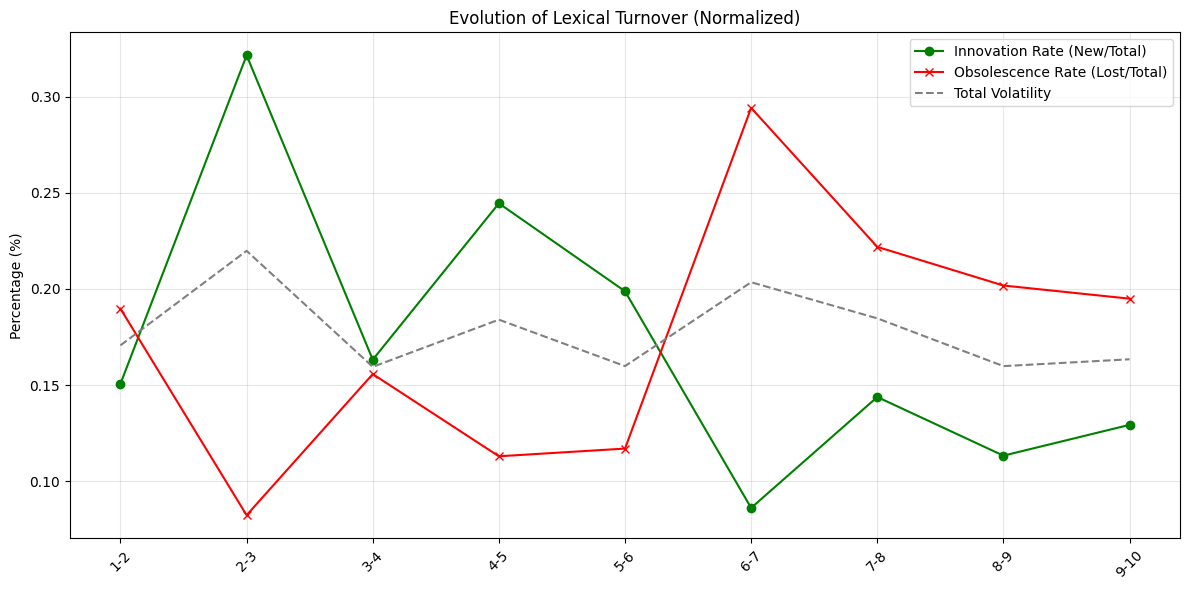

In [3]:
# Visualizzazione rapida trend

# Tasso di Innovazione, Obsolescenza e Volatilità nel tempo
plt.figure(figsize=(12, 6))
plt.plot(df_dyn['interval'], df_dyn['innovation_rate'], label='Innovation Rate (New/Total)', marker='o', color='green')
plt.plot(df_dyn['interval'], df_dyn['obsolescence_rate'], label='Obsolescence Rate (Lost/Total)', marker='x', color='red')
plt.plot(df_dyn['interval'], df_dyn['volatility'], label='Total Volatility', linestyle='--', color='grey')

plt.xticks(rotation=45)
plt.title("Evolution of Lexical Turnover (Normalized)")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

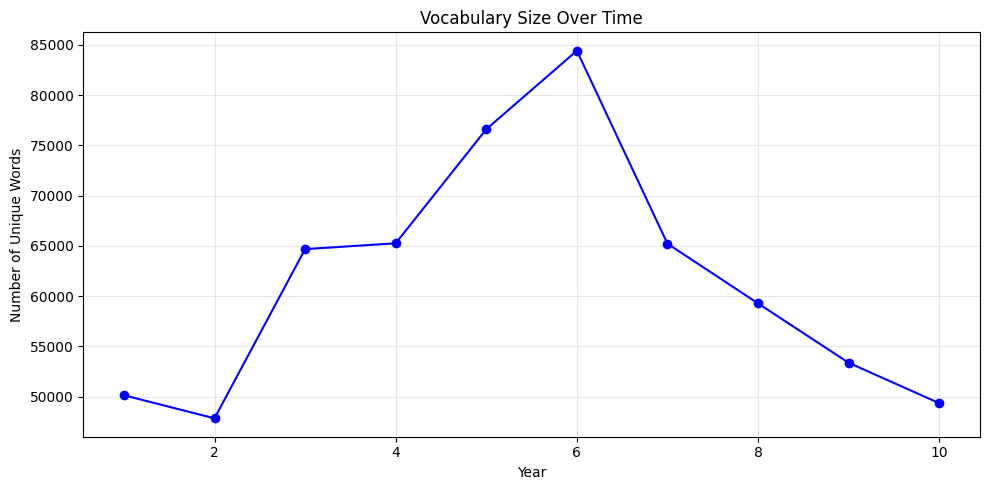

In [5]:
# dimensioni dei vocabolari nel tempo
vocab_sizes = []
for file in sorted_files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except:
        continue
        
    G = ig.Graph.Read_Pickle(str(input_dir / file))
    attr_name = 'token'
    words = set(G.vs[attr_name])
    vocab_sizes.append( (year, len(words)) )
    years, sizes = zip(*vocab_sizes)
plt.figure(figsize=(10, 5))
plt.plot(years, sizes, marker='o', color='blue')
plt.title("Vocabulary Size Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Unique Words")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# average jaccard similarity
avg_jaccard = df_dyn['jaccard'].mean()
print(f"\nAverage Jaccard Similarity across intervals: {avg_jaccard:.4f}") # quanto il vocabolario rimane in media simile da un intervallo al successivo
# average volatility
avg_volatility = df_dyn['volatility'].mean()
print(f"Average Volatility across intervals: {avg_volatility:.4f}") # quanto il vocabolario cambia in media da un intervallo al successivo
# average growth rate
avg_growth = df_dyn['growth_rate'].mean()
print(f"Average Growth Rate across intervals: {avg_growth:.4f}") # in media il vocabolario si espande o si contrae? (positivo = espansione, negativo = contrazione)
# average simpson overlap
avg_simpson = df_dyn['simpson_overlap'].mean()
print(f"Average Simpson's Overlap across intervals: {avg_simpson:.4f}") # quanto in media un intervallo è contenuto nell'altro (resistente a differenze di grandezza)
# average survival rate
avg_survival = df_dyn['innovation_rate'].mean()
print(f"Average Survival Rate across intervals: {avg_survival:.4f}") # in media quanto del vocabolario odierno è nuovo (non presente prima)
# average obsolescence rate
avg_obsolescence = df_dyn['obsolescence_rate'].mean()
print(f"Average Obsolescence Rate across intervals: {avg_obsolescence:.4f}") # in media quanto del vocabolario passato è andato perso (non presente dopo)

In [ ]:
# percentuale di parole complesse tra quelle perse (obsolescence) e tra quelle nuove (innovation)
# complessità = De Mauro alto



### 3.4) Complexity-dynamics correlation

Do the complex words tend to be the more volatile?

In [25]:
# Configurazione
input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

turnover_quality = []

print("Inizio analisi qualitativa del turnover...")

# Funzione helper per calcolare media attributi di un set di parole
def get_set_metrics(word_set, attribute_lookup_dict):
    """
    Calcola le medie di IDF, De Mauro e Lunghezza per un set di parole
    usando un dizionario di lookup {parola: {attr: val}}.
    """
    if not word_set:
        return 0, 0, 0
    
    idfs = []
    dms = [] # De Mauro (0=Semplice, 3=Complesso)
    lens = []
    syls = []
    
    for word in word_set:
        # Se per qualche motivo la parola non ha attributi (non dovrebbe succedere), saltiamo
        if word in attribute_lookup_dict:
            attrs = attribute_lookup_dict[word]
            idfs.append(attrs['idf'])
            dms.append(attrs['demauro_level'])
            lens.append(attrs['char_len'])
            syls.append(attrs['syll_len'])

    return np.mean(idfs), np.mean(dms), np.mean(lens), np.mean(syls)


# Ciclo sugli intervalli temporali
for i in range(len(files) - 1):
    file_t0 = files[i]
    file_t1 = files[i+1]
    
    t0 = int(file_t0.split("_")[1].replace("snap", ""))
    t1 = int(file_t1.split("_")[1].replace("snap", ""))
    
    print(f"Analisi intervallo {t0}-{t1}...", end="")
    
    # 1. Carichiamo i due grafi
    G0 = ig.Graph.Read_Pickle(str(input_dir / file_t0))
    G1 = ig.Graph.Read_Pickle(str(input_dir / file_t1))
    
    # 2. Creiamo dizionari di lookup veloci per gli attributi
    # Ci serve per non fare G.vs.find() dentro il ciclo (che è lento)
    # Nota: Usiamo 'name' o 'token' a seconda di come hai salvato
    attr_key = 'name' if 'name' in G0.vs.attributes() else 'token'
    
    # Lookup per il tempo T0 (serve per le parole STABILI e PERSE)
    lookup_t0 = {
        v[attr_key]: {
            'idf': v['idf'], 
            'demauro_level': v['demauro_level'], 
            'char_len': v['char_len'],
            'syll_len': v['syll_len']
        } for v in G0.vs
    }
    
    # Lookup per il tempo T1 (serve per le parole NUOVE)
    lookup_t1 = {
        v[attr_key]: {
            'idf': v['idf'], 
            'demauro_level': v['demauro_level'], 
            'char_len': v['char_len'],
            'syll_len': v['syll_len']
        } for v in G1.vs
    }
    
    # 3. Identifichiamo i Set
    set0 = set(lookup_t0.keys())
    set1 = set(lookup_t1.keys())
    
    stable_words = set0.intersection(set1) # Parole rimaste
    lost_words = set0 - set1               # Parole uscite
    new_words = set1 - set0                # Parole entrate
    
    # 4. Calcoliamo le metriche medie per ogni gruppo
    
    # A. Gruppo STABLE (Usiamo i valori di T0 come riferimento)
    stable_idf, stable_dm, stable_len, stable_syl = get_set_metrics(stable_words, lookup_t0)
    
    # B. Gruppo LOST (Usiamo i valori di T0, perché in T1 non esistono più)
    lost_idf, lost_dm, lost_len, lost_syl = get_set_metrics(lost_words, lookup_t0)
    
    # C. Gruppo NEW (Usiamo i valori di T1, perché in T0 non esistevano)
    new_idf, new_dm, new_len, new_syl = get_set_metrics(new_words, lookup_t1)
    
    turnover_quality.append({
        "interval": f"{t0}-{t1}",
        "year_start": t0,
        
        # IDF (Specificità)
        "idf_stable": stable_idf,
        "idf_lost": lost_idf,
        "idf_new": new_idf,
        
        # De Mauro (0=Semplice, 3=Complesso)
        "dm_stable": stable_dm,
        "dm_lost": lost_dm,
        "dm_new": new_dm,
        
        # Lunghezza (caratteri)
        "len_stable": stable_len,
        "len_lost": lost_len,
        "len_new": new_len,

        # Lunghezza (sillabe)
        "syl_stable": stable_syl,
        "syl_lost": lost_syl,
        "syl_new": new_syl,
        
        # Conteggi per contesto
        "count_lost": len(lost_words),
        "count_new": len(new_words)
    })
    
    print(" Fatto.")

df_qual = pd.DataFrame(turnover_quality)


Inizio analisi qualitativa del turnover...
Analisi intervallo 1-2... Fatto.
Analisi intervallo 2-3... Fatto.
Analisi intervallo 3-4... Fatto.
Analisi intervallo 4-5... Fatto.
Analisi intervallo 5-6... Fatto.
Analisi intervallo 6-7... Fatto.
Analisi intervallo 7-8... Fatto.
Analisi intervallo 8-9... Fatto.
Analisi intervallo 9-10... Fatto.


In [ ]:
# --- VISUALIZZAZIONE E INTERPRETAZIONE ---
print("\n--- ANALISI QUALITATIVA DEL TURNOVER ---")
print(df_qual[['interval', 'idf_stable', 'idf_lost', 'idf_new', 'dm_stable', 'dm_lost', 'dm_new', 'len_stable', 'len_lost', 'len_new', 'syl_stable', 'syl_lost', 'syl_new']])

# Calcoliamo il "Complexity Gap" medio (Lost - New)
# Se positivo, stiamo perdendo parole più complesse di quelle che entrano
df_qual['gap_idf'] = df_qual['idf_lost'] - df_qual['idf_new'] 
df_qual['gap_dm'] = df_qual['dm_lost'] - df_qual['dm_new']
df_qual['gap_len'] = df_qual['len_lost'] - df_qual['len_new']
df_qual['gap_syl'] = df_qual['syl_lost'] - df_qual['syl_new']

print(f"\nMedia Gap IDF (Lost - New): {df_qual['gap_idf'].median():.4f}")
print("(Se positivo: le parole perse erano più specifiche di quelle nuove)")

print(f"Media Gap De Mauro (Lost - New): {df_qual['gap_dm'].median():.4f}")
print("(Se positivo: le parole perse erano più 'difficili' di quelle nuove)")

print(f"Media Gap Lunghezza Caratteri (Lost - New): { (df_qual['gap_len']).median():.4f}")
print("(Se positivo: le parole perse erano più lunghe (in caratteri) di quelle nuove)")

print(f"Media Gap Lunghezza Sillabe (Lost - New): { (df_qual['gap_syl']).median():.4f}")
print("(Se positivo: le parole perse erano più lunghe (in sillabe) di quelle nuove)")


--- ANALISI QUALITATIVA DEL TURNOVER ---
  interval  idf_stable  idf_lost  idf_new  dm_stable  dm_lost   dm_new  len_stable  len_lost  len_new  syl_stable  syl_lost  syl_new
0      1-2   -0.018593  0.458448 0.392080   2.681308 2.982548 2.985441    8.206200  8.212574 8.707848    3.354195  3.329058 3.513311
1      2-3   -0.017420  0.719309 0.485270   2.703468 2.990872 2.986385    8.269392  8.420385 8.560377    3.379295  3.365872 3.478495
2      3-4    0.030284  0.761192 0.614051   2.757340 2.995236 2.987985    8.375309  8.295782 8.631841    3.420515  3.360596 3.475735
3      4-5    0.036412  0.825114 0.754227   2.769311 2.996476 2.992632    8.392017  8.614665 8.338655    3.424400  3.469775 3.359103
4      5-6    0.112097  0.964818 0.979600   2.801085 2.996097 2.995531    8.345487  8.631467 8.429993    3.403167  3.448149 3.364812
5      6-7    0.057753  0.828965 0.958558   2.774837 2.995529 2.996266    8.303702  8.502900 8.434388    3.382829  3.426051 3.295697
6      7-8    0.004340  0.5

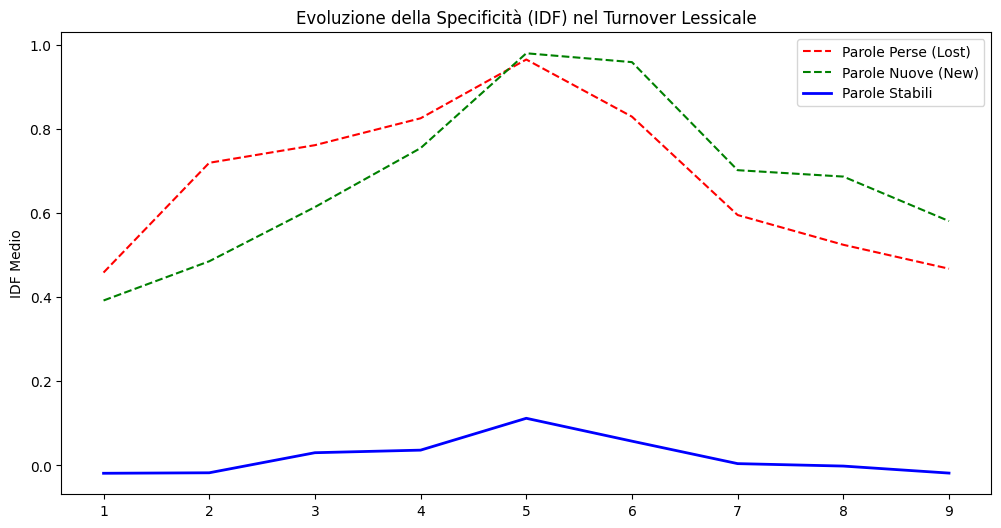

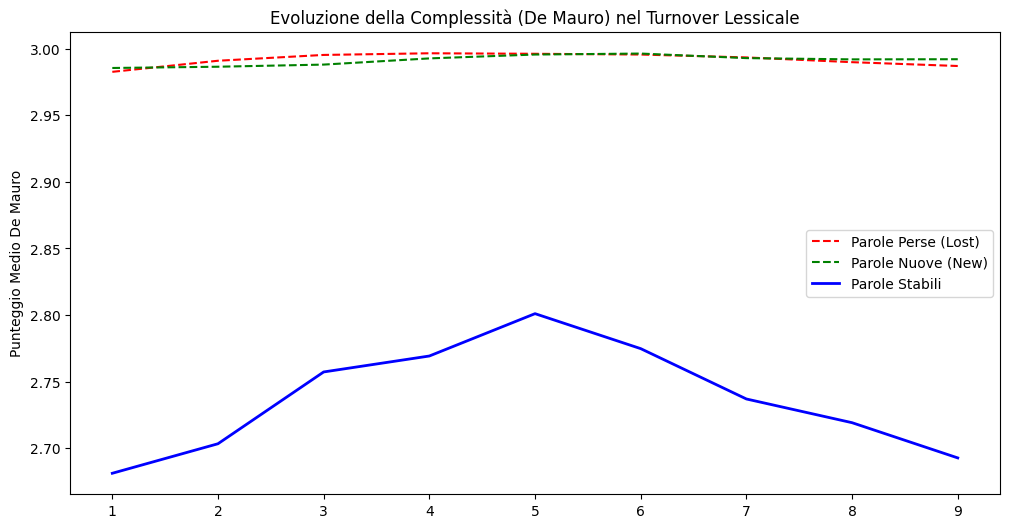

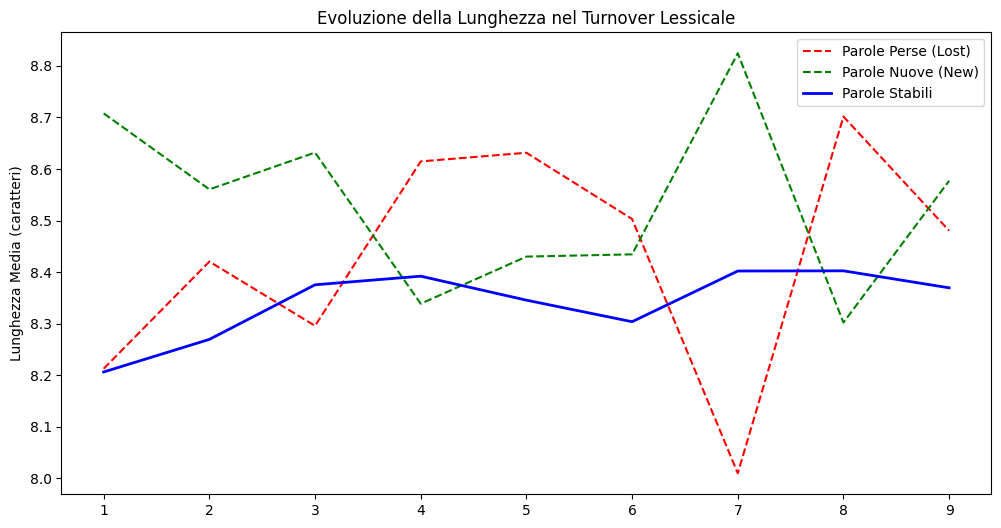

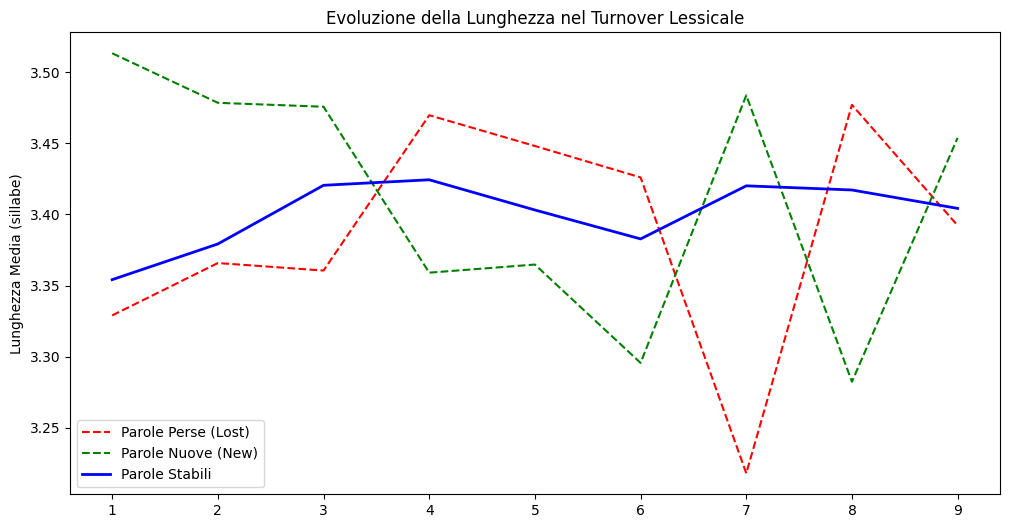

In [29]:
# plot IDF evolution

plt.figure(figsize=(12, 6))
plt.plot(df_qual['year_start'], df_qual['idf_lost'], label='Parole Perse (Lost)', color='red', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['idf_new'], label='Parole Nuove (New)', color='green', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['idf_stable'], label='Parole Stabili', color='blue', linewidth=2)

plt.title("Evoluzione della Specificità (IDF) nel Turnover Lessicale")
plt.ylabel("IDF Medio")
plt.legend()
plt.show()

# plot De Mauro evolution
plt.figure(figsize=(12, 6))
plt.plot(df_qual['year_start'], df_qual['dm_lost'], label='Parole Perse (Lost)', color='red', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['dm_new'], label='Parole Nuove (New)', color='green', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['dm_stable'], label='Parole Stabili', color='blue', linewidth=2)
plt.title("Evoluzione della Complessità (De Mauro) nel Turnover Lessicale")
plt.ylabel("Punteggio Medio De Mauro")
plt.legend()
plt.show()

# plot Length (in characters) evolution
plt.figure(figsize=(12, 6))
plt.plot(df_qual['year_start'], df_qual['len_lost'], label='Parole Perse (Lost)', color='red', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['len_new'], label='Parole Nuove (New)', color='green', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['len_stable'], label='Parole Stabili', color='blue', linewidth=2)
plt.title("Evoluzione della Lunghezza nel Turnover Lessicale")
plt.ylabel("Lunghezza Media (caratteri)")
plt.legend()
plt.show()

# plot Length (in syllables) evolution
plt.figure(figsize=(12, 6))
plt.plot(df_qual['year_start'], df_qual['syl_lost'], label='Parole Perse (Lost)', color='red', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['syl_new'], label='Parole Nuove (New)', color='green', linestyle='--')
plt.plot(df_qual['year_start'], df_qual['syl_stable'], label='Parole Stabili', color='blue', linewidth=2)
plt.title("Evoluzione della Lunghezza nel Turnover Lessicale")
plt.ylabel("Lunghezza Media (sillabe)")
plt.legend()
plt.show()

### 3.5) Analyzing simple words' centrality across time

In [ ]:
from scipy.stats import spearmanr

# Configurazione
input_dir = Path("networks_annotated") # Cartella coi grafi annotati
files = sorted([f for f in os.listdir(input_dir) if "snap" in f])

results = []

print("Inizio analisi correlazione Complessità-Centralità...")

for file in files:
    # 1. Estrazione anno
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except:
        continue
        
    # 2. Caricamento Grafo
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    num_nodes = G.vcount()
    
    if num_nodes == 0: continue

    # 3. Estrazione Metriche di Centralità
    # Strength = Weighted Degree (Somma dei pesi degli archi incidenti)
    # È meglio del degree semplice perché conta la frequenza di co-occorrenza
    strength = np.array(G.strength(weights='weight'))
    
    # Normalizziamo la strength per rendere confrontabili anni con n. nodi diversi
    # (diviso N-1)
    norm_strength = strength / (num_nodes - 1)
    
    # PageRank (Importanza globale nel flusso informativo)
    pagerank = np.array(G.pagerank(weights='weight'))

    # 4. Estrazione Attributi di Complessità (già calcolati prima)
    # Recuperiamo le liste dagli attributi del grafo
    demauro_vals = np.array(G.vs['demauro_level']) # 0=FO, 1=AU, 2=AD, 3=Altro
    idf_vals = np.array(G.vs['idf'])               # Basso=Generico, Alto=Specifico
    char_len_vals = np.array(G.vs['char_len']) # Alto=Complesso, Basso=Semplice
    
    # --- ANALISI A: CORRELAZIONI (Spearman) ---
    # Usiamo Spearman perché le variabili non sono necessariamente distribuite normalmente
    
    # Ipotesi: Più alto DeMauro (3=Complesso), più bassa Centralità -> Corr Negativa
    corr_dm_deg, _ = spearmanr(demauro_vals, norm_strength)
    
    # Ipotesi: Più alto IDF (Specifico), più bassa Centralità -> Corr Negativa
    corr_idf_deg, _ = spearmanr(idf_vals, norm_strength)

    # Ipotesi: Più lunga la parola (in caratteri), più bassa Centralità -> Corr Negativa
    corr_len_deg, _ = spearmanr(char_len_vals, norm_strength)

    # Ipotesi: Più lunga la parola (in sillabe), più bassa Centralità -> Corr Negativa
    syl_len_vals = np.array(G.vs['syll_len']) # Alto=Complesso, Basso=Semplice
    corr_syl_deg, _ = spearmanr(syl_len_vals, norm_strength)
    
    # --- ANALISI B: MEDIE PER GRUPPO (Il Gap) ---
    # Creiamo una maschera per parole "Semplici" (Fondamentali - 0) vs "Complesse" (Altro - 3)
    mask_simple = (demauro_vals == 0) # FO
    mask_complex = (demauro_vals == 3) # Altro/Non in dizionario
    
    avg_cent_simple = np.mean(norm_strength[mask_simple]) if np.any(mask_simple) else 0
    avg_cent_complex = np.mean(norm_strength[mask_complex]) if np.any(mask_complex) else 0
    
    # Calcoliamo il ratio (quanto le semplici sono più centrali delle complesse)
    ratio_simple_complex = avg_cent_simple / avg_cent_complex if avg_cent_complex > 0 else 0

    results.append({
        "year": year,
        "corr_demauro_centrality": corr_dm_deg,
        "corr_idf_centrality": corr_idf_deg,
        "avg_centrality_simple": avg_cent_simple,
        "avg_centrality_complex": avg_cent_complex,
        "dominance_ratio": ratio_simple_complex,
        "corr_length_centrality": corr_len_deg,
        "corr_syllable_length_centrality": corr_syl_deg
    })


Inizio analisi correlazione Complessità-Centralità...

--- RISULTATI ANALISI ---
   year  corr_demauro_centrality  corr_idf_centrality  avg_centrality_simple  \
1     1                -0.004257            -0.006185               0.005765   
2     2                -0.001445            -0.008260               0.005834   
3     3                 0.001766             0.000229               0.005789   
4     4                -0.002257            -0.005351               0.005921   
5     5                -0.003124             0.001261               0.005734   

   avg_centrality_complex  dominance_ratio  corr_length_centrality  \
1                0.005592         1.030881               -0.002628   
2                0.005566         1.048031                0.008814   
3                0.005636         1.027098                0.002706   
4                0.005715         1.036021                0.001002   
5                0.005647         1.015539                0.006308   

   corr_syllable_

In [11]:
df_trends = pd.DataFrame(results).sort_values("year")

print("\n--- RISULTATI ANALISI ---")
print(df_trends)



--- RISULTATI ANALISI ---
   year  corr_demauro_centrality  corr_idf_centrality  avg_centrality_simple  \
1     1                -0.004257            -0.006185               0.005765   
2     2                -0.001445            -0.008260               0.005834   
3     3                 0.001766             0.000229               0.005789   
4     4                -0.002257            -0.005351               0.005921   
5     5                -0.003124             0.001261               0.005734   
6     6                -0.000410            -0.000802               0.005492   
7     7                 0.003968             0.000817               0.005666   
8     8                 0.005817             0.007449               0.005410   
9     9                -0.001892            -0.003525               0.005678   
0    10                -0.005587            -0.005358               0.005732   

   avg_centrality_complex  dominance_ratio  corr_length_centrality  \
1                0.005

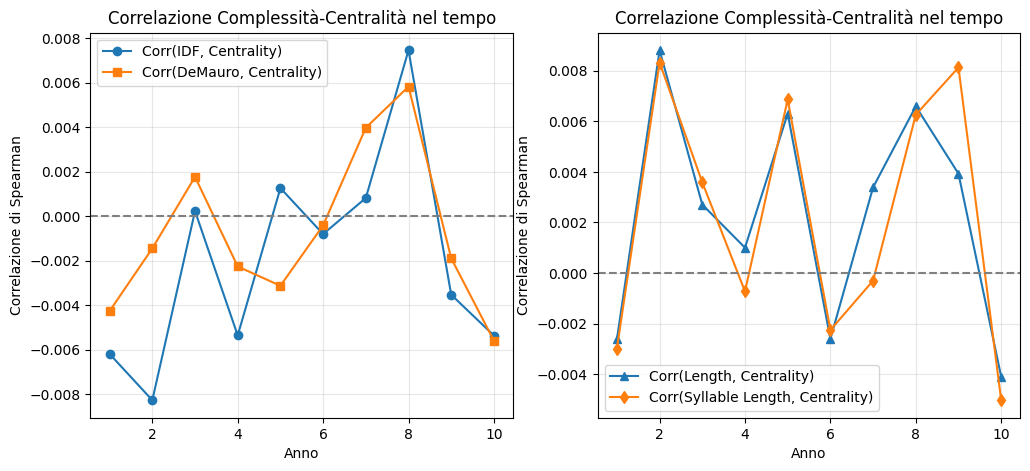

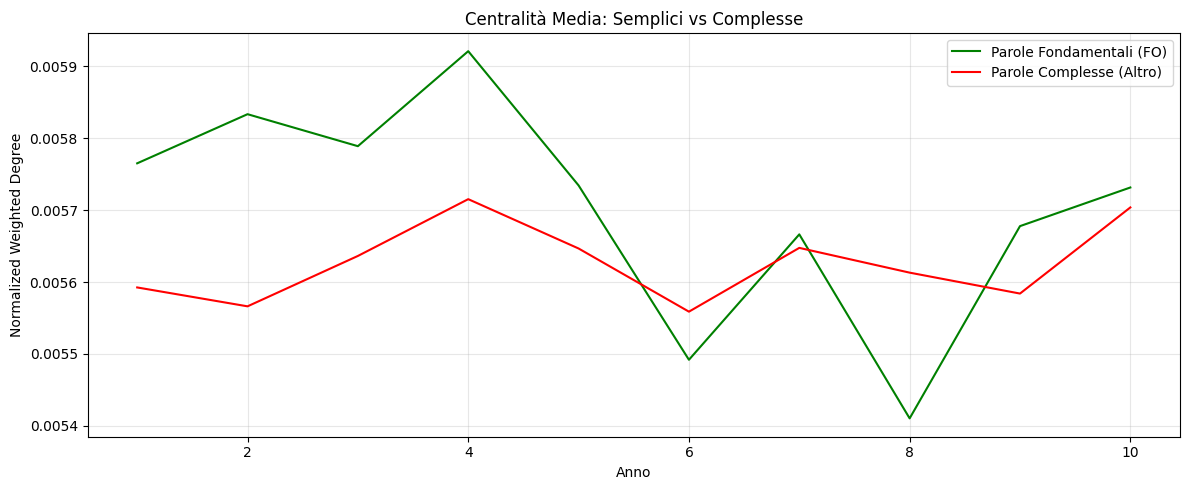

In [5]:

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(12, 5))

# Plot 1: Evoluzione delle Correlazioni
plt.subplot(1, 2, 1)
plt.plot(df_trends['year'], df_trends['corr_idf_centrality'], marker='o', label="Corr(IDF, Centrality)")
plt.plot(df_trends['year'], df_trends['corr_demauro_centrality'], marker='s', label="Corr(DeMauro, Centrality)")
plt.title("Correlazione Complessità-Centralità nel tempo")
plt.xlabel("Anno")
plt.ylabel("Correlazione di Spearman")
plt.axhline(0, color='grey', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Gap Semplici vs Complesse
plt.subplot(1, 2, 2)
plt.plot(df_trends['year'], df_trends['corr_length_centrality'], marker='^', label="Corr(Length, Centrality)")
plt.plot(df_trends['year'], df_trends['corr_syllable_length_centrality'], marker='d', label="Corr(Syllable Length, Centrality)")
plt.title("Correlazione Complessità-Centralità nel tempo")
plt.xlabel("Anno")
plt.ylabel("Correlazione di Spearman")
plt.axhline(0, color='grey', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Il Gap Semplici vs Complesse
plt.figure(figsize=(12, 5))
plt.plot(df_trends['year'], df_trends['avg_centrality_simple'], color='green', label="Parole Fondamentali (FO)")
plt.plot(df_trends['year'], df_trends['avg_centrality_complex'], color='red', label="Parole Complesse (Altro)")
plt.title("Centralità Media: Semplici vs Complesse")
plt.xlabel("Anno")
plt.ylabel("Normalized Weighted Degree")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Salva dati
df_trends.to_csv("centrality_complexity_trends.csv", index=False)

In [7]:
import random
import numpy as np

def estimate_betweenness_pivot(G, k=500):
    """
    Stima la betweenness usando solo k sorgenti casuali.
    """
    nodes = G.vs.indices
    # Se il grafo è piccolo, usa tutti, altrimenti campiona
    if len(nodes) > k:
        sources = random.sample(nodes, k)
    else:
        sources = nodes
        
    # estimate_betweenness di igraph accetta una lista di sorgenti
    # cutoff=3 o 4 aiuta ulteriormente
    est = G.betweenness(vertices=G.vs, cutoff=4, weights='weight') 
    
    # Nota: igraph calcola la betweenness *dei* nodi specificati, 
    # non *usando* quei nodi come sorgenti uniche per gli altri.
    # Quindi su igraph, la strategia migliore resta il CUTOFF.
    
    return est

In [ ]:
from scipy.stats import spearmanr

input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

multi_metric_results = []

print("Inizio analisi Multi-Centralità...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Analisi {year}...", end="")
    
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    N = G.vcount()
    if N == 0: continue

    # --- 1. ESTRAZIONE CENTRALITÀ ---
    
    # A. PageRank (Già fatta, teniamola come baseline)
    pagerank = np.array(G.pagerank(weights='weight'))
    
    # B. Weighted Degree (Strength) - Veloce e fondamentale
    strength = np.array(G.strength(weights='weight'))
    # Normalizzazione (fondamentale per confronti temporali)
    strength_norm = strength / (N - 1)
    
    # C. Betweenness (Stimata con cutoff per velocità)
    # cutoff=3 significa che guardiamo solo percorsi lunghi fino a 3 passi. 
    # Nelle reti semantiche "small world", 3-4 passi coprono quasi tutto.
    # Se la rete non è immensa, prova senza cutoff, ma con 50k nodi è rischioso.
    betweenness = estimate_betweenness_pivot(G, k=500)
    # Normalizzazione Betweenness: B / ((N-1)(N-2)/2)
    denom = ((500 - 1) * (500 - 2)) / 2
    betw_norm = betweenness / denom if denom > 0 else betweenness
    
    # --- 2. ESTRAZIONE COMPLESSITÀ ---
    # Usiamo l'IDF come proxy numerico continuo (migliore per correlazioni rispetto a DeMauro discreto)
    if 'idf' in G.vs.attributes():
        complexity_vals = np.array(G.vs['idf'])
        metric_name = "IDF"
    else:
        # Fallback su lunghezza se manca IDF
        complexity_vals = np.array(G.vs['char_len'])
        metric_name = "Len"

    # --- 3. CORRELAZIONI (Spearman) ---
    # Ci aspettiamo valori negativi (Alta complessità -> Bassa centralità)
    
    corr_pr, _ = spearmanr(complexity_vals, pagerank)
    corr_deg, _ = spearmanr(complexity_vals, strength_norm)
    corr_betw, _ = spearmanr(complexity_vals, betw_norm)
    
    multi_metric_results.append({
        "year": year,
        "corr_PageRank": corr_pr,
        "corr_Strength": corr_deg,
        "corr_Betweenness": corr_betw
    })
    
    print(" Fatto.")

df_multi = pd.DataFrame(multi_metric_results)

# --- VISUALIZZAZIONE COMPARATIVA ---
plt.figure(figsize=(10, 6))

plt.plot(df_multi['year'], df_multi['corr_Strength'], marker='o', label='Weighted Degree (Popolarità)', color='blue')
plt.plot(df_multi['year'], df_multi['corr_PageRank'], marker='s', label='PageRank (Prestigio)', color='green')
plt.plot(df_multi['year'], df_multi['corr_Betweenness'], marker='^', label='Betweenness (Ponte)', color='red')

plt.title(f"Correlazione tra {metric_name} (Complessità) e Centralità")
plt.xlabel("Anno")
plt.ylabel("Spearman Correlation")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(df_multi.head())

Inizio analisi Multi-Centralità...
Analisi 1...